# Bonus Exercise 

### Problem Overview

We have a chemostat with mixed-growth-associated product formation. The goal is to find the dilution rate $D$ that maximises:
- **(a)** Product productivity $D \cdot P$
- **(b)** Biomass productivity $D \cdot X$

### Setup

We define all given parameters and import the optimizer. Since both productivities are explicit functions of $D$, we use `scipy.optimize.minimize_scalar` with bounded search over $0 < D < D_{\text{crit}}$.

### Kinetic model

| Equation | Expression |
|---|---|
| Monod growth | $\mu = \dfrac{\mu_m S}{K_S + S}$ |
| Substrate consumption | $r_S = \dfrac{\mu X}{Y_{X/S}^{\max}}$ |
| Specific product rate | $q_P = \alpha\,\mu + \beta$ |

### Given parameters

| Symbol | Value | Units |
|---|---|---|
| $\mu_m$ | 0.7 | h⁻¹ |
| $K_S$ | 20 | mg/L |
| $Y_{X/S}^{\max}$ | 0.5 | g cells / g substrate |
| $\alpha$ | 0.1 | — |
| $\beta$ | 0.02 | h⁻¹ |
| $S_0$ | 1 | g/L |
| $P_0$ | 0 | g/L |


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar

# Parameters
mu_m     = 0.7      # h^-1
K_S      = 20e-3    # g/L  (20 mg/L)
Y_xs_max = 0.5      # g cells / g substrate
alpha    = 0.1      # growth-associated coefficient
beta     = 0.02     # non-growth-associated coefficient (h^-1)
S_0      = 1.0      # g/L, feed substrate concentration

### Steady-state function

This function evaluates the steady-state equations for a given $D$ and returns all concentrations and productivities. Returns `None` at washout.

In [10]:
def steady_state(D):
    """Compute steady-state S, X, P and productivities for a given D."""
    if D <= 0 or D >= mu_m:
        return None
    S = K_S * D / (mu_m - D)
    if S >= S_0:  # washout
        return None
    X = Y_xs_max * (S_0 - S)
    q_p = alpha * D + beta
    P = q_p * X / D
    Prod_P = D * P          # = (alpha*D + beta) * X
    Prod_X = D * X
    return S, X, P, q_p, Prod_P, Prod_X

# Washout dilution rate
D_crit = mu_m * S_0 / (K_S + S_0)
print(f"D_crit = {D_crit:.4f} h^-1")

D_crit = 0.6863 h^-1


### Optimization

We minimize the negative of each productivity over the feasible range. `minimize_scalar` with `method='bounded'`. The two code snippets are used to answer the questions of part a) and part b).

In [11]:
# (a) Product productivity
def neg_prod_P(D):
    result = steady_state(D)
    return -result[4] if result else 0.0

res_P = minimize_scalar(neg_prod_P, bounds=(1e-6, D_crit - 1e-6), method='bounded')
D_opt_P = res_P.x
ss_P = steady_state(D_opt_P)

print("(a) Max product productivity")
print(f"D_opt,P  = {D_opt_P:.4f} h^-1")
print(f"S = {ss_P[0]*1000:.1f} mg/L")
print(f"X = {ss_P[1]:.4f} g/L")
print(f"P = {ss_P[2]:.4f} g/L")
print(f"Prod_P = {ss_P[4]:.4f} g/L/h")

(a) Max product productivity
D_opt,P  = 0.5889 h^-1
S = 106.0 mg/L
X = 0.4470 g/L
P = 0.0599 g/L
Prod_P = 0.0353 g/L/h


In [12]:
# (b) Biomass productivity
def neg_prod_X(D):
    result = steady_state(D)
    return -result[5] if result else 0.0

res_X = minimize_scalar(neg_prod_X, bounds=(1e-6, D_crit - 1e-6), method='bounded')
D_opt_X = res_X.x
ss_X = steady_state(D_opt_X)

# Analytical verification
D_opt_X_ana = mu_m * (1 - np.sqrt(K_S / (K_S + S_0)))

print("(b) Max biomass productivity")
print(f"D_opt,X (numerical)   = {D_opt_X:.4f} h^-1")
print(f"D_opt,X (analytical)  = {D_opt_X_ana:.4f} h^-1")
print(f"S = {ss_X[0]*1000:.1f} mg/L")
print(f"X = {ss_X[1]:.4f} g/L")
print(f"Prod_X = {ss_X[5]:.4f} g/L/h")

(b) Max biomass productivity
D_opt,X (numerical)   = 0.6020 h^-1
D_opt,X (analytical)  = 0.6020 h^-1
S = 122.8 mg/L
X = 0.4386 g/L
Prod_X = 0.2640 g/L/h


### Plots

We sweep $D$ from near-zero to just below $D_{\text{crit}}$ and plot concentrations and productivities.

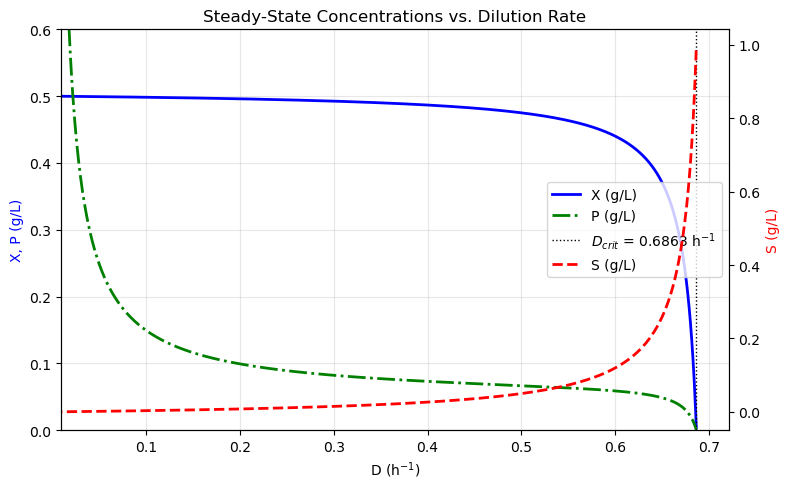

In [13]:
D_range = np.linspace(1e-4, D_crit - 1e-4, 1000)
S_arr, X_arr, P_arr, ProdP_arr, ProdX_arr = [np.zeros_like(D_range) for _ in range(5)]

for i, D in enumerate(D_range):
    result = steady_state(D)
    if result is not None:
        S_arr[i], X_arr[i], P_arr[i], _, ProdP_arr[i], ProdX_arr[i] = result

# --- Concentrations (dual y-axis) ---
fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(D_range, X_arr, 'b-', lw=2, label='X (g/L)')
ax1.plot(D_range, P_arr, 'g-.', lw=2, label='P (g/L)')
ax1.axvline(D_crit, color='k', ls=':', lw=1, label=f'$D_{{crit}}$ = {D_crit:.4f} h$^{{-1}}$')
ax1.set_xlabel('D (h$^{-1}$)'); ax1.set_ylabel('X, P (g/L)', color='b')
ax1.set_xlim([0.01, D_crit * 1.05]); ax1.set_ylim([0, 0.6]); ax1.grid(alpha=0.3)

ax1b = ax1.twinx()
ax1b.plot(D_range, S_arr, 'r--', lw=2, label='S (g/L)')
ax1b.set_ylabel('S (g/L)', color='r')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1b.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right')
ax1.set_title('Steady-State Concentrations vs. Dilution Rate')
plt.tight_layout(); plt.show()

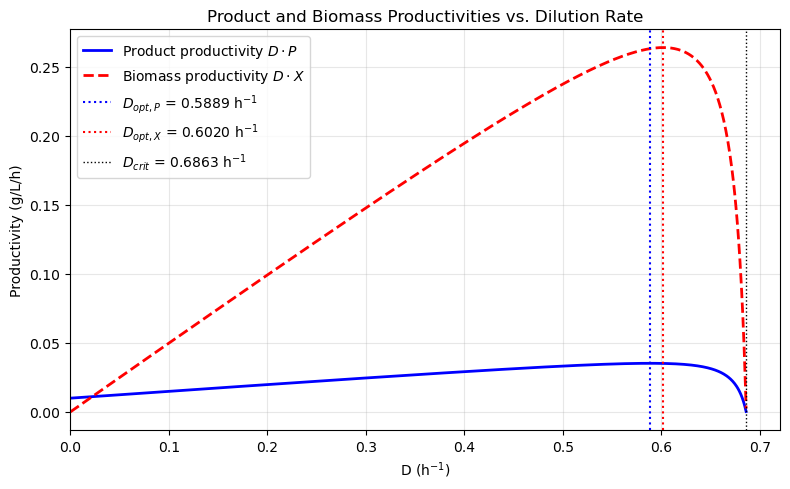

In [14]:
# Productivities
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(D_range, ProdP_arr, 'b-', lw=2, label='Product productivity $D \\cdot P$')
ax.plot(D_range, ProdX_arr, 'r--', lw=2, label='Biomass productivity $D \\cdot X$')
ax.axvline(D_opt_P, color='b', ls=':', lw=1.5, label=f'$D_{{opt,P}}$ = {D_opt_P:.4f} h$^{{-1}}$')
ax.axvline(D_opt_X, color='r', ls=':', lw=1.5, label=f'$D_{{opt,X}}$ = {D_opt_X:.4f} h$^{{-1}}$')
ax.axvline(D_crit, color='k', ls=':', lw=1, label=f'$D_{{crit}}$ = {D_crit:.4f} h$^{{-1}}$')
ax.set_xlabel('D (h$^{-1}$)'); ax.set_ylabel('Productivity (g/L/h)')
ax.set_xlim([0, D_crit * 1.05]); ax.legend(); ax.grid(alpha=0.3)
ax.set_title('Product and Biomass Productivities vs. Dilution Rate')
plt.tight_layout(); plt.show()